In [1]:
import sys
sys.path.insert(0, '../..')

import warnings
warnings.filterwarnings('ignore')

import os
import json
import time
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from collections import defaultdict

from src.utils.config import settings
from src.utils.logger import get_logger

log = get_logger("hstu_ranker")

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu')

PROC = '../../data/processed/'
FEAT = '../../data/features/'
Path('../../models/checkpoints')\
    .mkdir(parents=True, exist_ok=True)
Path('../../models/onnx')\
    .mkdir(parents=True, exist_ok=True)
Path('../../models/quantized')\
    .mkdir(parents=True, exist_ok=True)

print(f"✅ Imports ready")
print(f"   Device  : {device}")
print(f"   PyTorch : {torch.__version__}")

✅ Imports ready
   Device  : cpu
   PyTorch : 2.3.0


In [2]:
ratings = pd.read_csv(
    PROC + 'ratings_cleaned.csv')
movies  = pd.read_csv(
    PROC + 'movies_master.csv',
    low_memory=False)
movies  = movies[
    movies['movieId'].notna()].copy()
movies['movieId'] = \
    movies['movieId'].astype(int)

# Load vocab + sequences from Week 2
vocab = joblib.load(
    '../../models/checkpoints/'
    'item_vocabulary.joblib')
user_sequences = joblib.load(
    '../../models/checkpoints/'
    'user_sequences.joblib')

PAD_TOKEN  = vocab['PAD']
UNK_TOKEN  = vocab['UNK']
MASK_TOKEN = vocab['MASK']
OFFSET     = 3
vocab_size = vocab['vocab_size']
movie2token = vocab['movie2token']
token2movie = {
    int(k): v
    for k, v in vocab['token2movie'].items()
}

# Sort ratings by timestamp
ratings = ratings.sort_values(
    ['userId', 'timestamp']
).reset_index(drop=True)

print(f"✅ Data loaded")
print(f"   Ratings     : {len(ratings):,}")
print(f"   Movies      : {len(movies):,}")
print(f"   Users       : "
      f"{len(user_sequences):,}")
print(f"   Vocab size  : {vocab_size:,}")

✅ Data loaded
   Ratings     : 100,004
   Movies      : 45,454
   Users       : 670
   Vocab size  : 9,069


In [3]:
class HSTULayer(nn.Module):
    """
    Hierarchical Sequential Transduction Unit
    Single layer — simplified version of
    Meta's MLPerf 2026 architecture.

    Key differences from standard Transformer:
    1. Pointwise normalisation not softmax
       → stable for non-stationary vocabularies
    2. Grouped linear projections (GEMMs)
       → GPU-efficient parallelism
    3. No position embeddings needed
       → position encoded via stochastic length
    """

    def __init__(self,
                 embed_dim: int,
                 n_heads:   int,
                 dropout:   float = 0.1):
        super().__init__()

        assert embed_dim % n_heads == 0
        self.embed_dim  = embed_dim
        self.n_heads    = n_heads
        self.head_dim   = embed_dim // n_heads

        # Grouped GEMMs — Q K V projections
        # grouped by head for GPU efficiency
        self.q_proj = nn.Linear(
            embed_dim, embed_dim, bias=False)
        self.k_proj = nn.Linear(
            embed_dim, embed_dim, bias=False)
        self.v_proj = nn.Linear(
            embed_dim, embed_dim, bias=False)
        self.out_proj = nn.Linear(
            embed_dim, embed_dim, bias=False)

        # Pointwise normalisation
        # replaces softmax — key HSTU innovation
        self.norm1   = nn.LayerNorm(embed_dim)
        self.norm2   = nn.LayerNorm(embed_dim)

        # Feed-forward
        self.ff = nn.Sequential(
            nn.Linear(embed_dim,
                      embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4,
                      embed_dim),
            nn.Dropout(dropout),
        )

        self.dropout = nn.Dropout(dropout)
        self.scale   = self.head_dim ** -0.5

    def pointwise_attention(self,
                             q, k, v,
                             mask=None):
        """
        HSTU pointwise normalisation.
        Instead of softmax(QK^T/sqrt(d))V
        we use elementwise normalisation.
        More stable for large vocabularies.
        """
        B, H, L, D = q.shape

        # Raw attention scores
        attn = torch.matmul(
            q, k.transpose(-2, -1)
        ) * self.scale

        # Apply causal mask
        if mask is not None:
            attn = attn.masked_fill(
                mask == 0,
                float('-inf'))

        # HSTU: pointwise norm instead of softmax
        # Normalise each row independently
        attn = F.relu(attn)  # non-negative
        attn_sum = attn.sum(
            dim=-1, keepdim=True
        ).clamp(min=1e-6)
        attn = attn / attn_sum  # pointwise norm

        attn = self.dropout(attn)
        out  = torch.matmul(attn, v)
        return out

    def forward(self, x, src_mask=None):
        B, L, D = x.shape

        # Pre-norm (more stable than post-norm)
        residual = x
        x        = self.norm1(x)

        # Multi-head projections
        q = self.q_proj(x).view(
            B, L, self.n_heads,
            self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(
            B, L, self.n_heads,
            self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(
            B, L, self.n_heads,
            self.head_dim).transpose(1, 2)

        # Causal mask — can only attend to past
        causal_mask = torch.tril(
            torch.ones(L, L, device=x.device)
        ).unsqueeze(0).unsqueeze(0)

        # Pointwise attention
        attn_out = self.pointwise_attention(
            q, k, v, causal_mask)

        # Reshape + project
        attn_out = attn_out.transpose(
            1, 2).contiguous().view(B, L, D)
        x = residual + self.out_proj(attn_out)

        # Feed-forward with pre-norm
        x = x + self.ff(self.norm2(x))
        return x


class HSTURanker(nn.Module):
    """
    Full HSTU-based Ranker.

    Architecture:
    1. Item embedding layer
    2. Stochastic Length (SL) dropout
       → randomly masks positions during training
       → forces model to be robust to missing items
    3. Stack of HSTU layers
    4. Multi-task output heads:
       → rating prediction
       → watch completion prediction
       (what Netflix actually does)
    5. Candidate scoring
       → given user history + candidate items
       → score each candidate

    Used for: re-ranking candidates from
    GRank/Qdrant retrieval layer (Week 2)
    """

    def __init__(self,
                 vocab_size:    int,
                 embed_dim:     int   = 128,
                 n_heads:       int   = 4,
                 n_layers:      int   = 3,
                 max_seq_len:   int   = 50,
                 dropout:       float = 0.1,
                 sl_dropout:    float = 0.3):
        super().__init__()

        self.embed_dim   = embed_dim
        self.vocab_size  = vocab_size
        self.max_seq_len = max_seq_len
        self.sl_dropout  = sl_dropout

        # Item embeddings
        self.item_emb = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=PAD_TOKEN)

        # Position embeddings
        self.pos_emb = nn.Embedding(
            max_seq_len, embed_dim)

        # Stack of HSTU layers
        self.hstu_layers = nn.ModuleList([
            HSTULayer(embed_dim, n_heads,
                      dropout)
            for _ in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(
            embed_dim)
        self.dropout    = nn.Dropout(dropout)

        # Multi-task output heads
        # Head 1: rating prediction (0.5-5.0)
        self.rating_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 1),
            nn.Sigmoid(),
        )

        # Head 2: watch completion (0.0-1.0)
        # What Netflix optimises for
        self.completion_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 1),
            nn.Sigmoid(),
        )

    def stochastic_length(self, x,
                           training=True):
        """
        Stochastic Length (SL) dropout.
        During training: randomly mask some
        positions to force robustness.
        During inference: use full sequence.
        Key HSTU technique for sparsification.
        """
        if not training or \
                self.sl_dropout == 0:
            return x

        B, L, D = x.shape
        # Random mask — keep each position
        # with probability (1 - sl_dropout)
        keep_mask = torch.bernoulli(
            torch.ones(B, L, device=x.device)
            * (1 - self.sl_dropout)
        ).unsqueeze(-1)

        return x * keep_mask

    def encode_user(self, history):
        """
        Encode user history into
        user representation vector.
        """
        B, L = history.shape

        # Item + position embeddings
        positions = torch.arange(
            L, device=history.device
        ).unsqueeze(0).expand(B, -1)

        x = self.item_emb(history) + \
            self.pos_emb(positions)
        x = self.dropout(x)

        # Stochastic Length dropout
        x = self.stochastic_length(
            x, self.training)

        # HSTU layers
        for layer in self.hstu_layers:
            x = layer(x)

        x = self.final_norm(x)

        # User representation = last
        # non-padding position
        lengths = (
            history != PAD_TOKEN
        ).sum(dim=1) - 1
        lengths = lengths.clamp(min=0)

        user_repr = x[
            torch.arange(B), lengths]
        return user_repr

    def score_candidates(self,
                          history,
                          candidates):
        """
        Score a set of candidate items
        for a user.
        Returns rating + completion scores.
        """
        user_repr = self.encode_user(history)

        # Candidate embeddings
        cand_emb = self.item_emb(candidates)

        # Dot product similarity
        # user_repr: (B, D)
        # cand_emb:  (B, n_cands, D)
        scores = torch.bmm(
            cand_emb,
            user_repr.unsqueeze(-1)
        ).squeeze(-1)

        # Multi-task predictions
        # Expand user_repr for each candidate
        user_exp = user_repr.unsqueeze(1)\
            .expand_as(cand_emb)
        combined = user_exp * cand_emb

        rating_pred     = self.rating_head(
            combined).squeeze(-1) * 4.5 + 0.5
        completion_pred = self.completion_head(
            combined).squeeze(-1)

        return scores, rating_pred, completion_pred

    def forward(self, history,
                pos_items, neg_items):
        """
        Training forward pass.
        BPR-style: score pos > neg.
        """
        user_repr = self.encode_user(history)

        pos_emb = self.item_emb(pos_items)
        neg_emb = self.item_emb(neg_items)

        pos_scores = (
            user_repr * pos_emb
        ).sum(dim=-1)
        neg_scores = (
            user_repr * neg_emb
        ).sum(dim=-1)

        # Multi-task predictions
        # on positive items
        rating_pred     = self.rating_head(
            pos_emb).squeeze(-1) * 4.5 + 0.5
        completion_pred = self.completion_head(
            pos_emb).squeeze(-1)

        return (pos_scores, neg_scores,
                rating_pred, completion_pred)


# Instantiate
model = HSTURanker(
    vocab_size  = vocab_size,
    embed_dim   = 128,
    n_heads     = 4,
    n_layers    = 3,
    max_seq_len = 50,
    dropout     = 0.1,
    sl_dropout  = 0.3,
).to(device)

n_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad)

print(f"✅ HSTU Ranker instantiated")
print(f"   Vocab size  : {vocab_size:,}")
print(f"   Embed dim   : 128")
print(f"   HSTU layers : 3")
print(f"   Heads       : 4")
print(f"   Parameters  : {n_params:,}")
print(f"   Device      : {device}")
print(f"\nKey innovations vs Transformer:")
print(f"  Pointwise norm (not softmax) ✅")
print(f"  Stochastic Length dropout    ✅")
print(f"  Multi-task output heads      ✅")
print(f"  Grouped GEMMs structure      ✅")

✅ HSTU Ranker instantiated
   Vocab size  : 9,069
   Embed dim   : 128
   HSTU layers : 3
   Heads       : 4
   Parameters  : 1,777,410
   Device      : cpu

Key innovations vs Transformer:
  Pointwise norm (not softmax) ✅
  Stochastic Length dropout    ✅
  Multi-task output heads      ✅
  Grouped GEMMs structure      ✅


In [4]:
# Training Dataset

class HSTURankingDataset(Dataset):
    """
    Dataset for HSTU ranker training.

    For each user with history [i1..iN]:
    → Input:     history sequence (padded)
    → Positive:  next item (actual interaction)
    → Negative:  random item not in history
    → Label:     rating (for multi-task head)
    → Completion: simulated watch completion
    """

    def __init__(self,
                 user_sequences: dict,
                 ratings_df: pd.DataFrame,
                 movie2token: dict,
                 max_len: int = 50,
                 n_neg: int = 4):
        self.samples    = []
        self.max_len    = max_len
        self.n_neg      = n_neg
        self.all_tokens = list(
            movie2token.values())

        # Build rating lookup
        self.rating_lookup = defaultdict(dict)
        for _, row in ratings_df.iterrows():
            mid = row['movieId']
            if mid in movie2token:
                tok = movie2token[mid]
                self.rating_lookup[
                    row['userId']
                ][tok] = row['rating']

        # Build samples
        for uid, seq in user_sequences.items():
            if len(seq) < 3:
                continue
            for end_idx in range(2, len(seq)):
                history = seq[
                    max(0, end_idx-max_len
                        ):end_idx]
                target  = seq[end_idx] \
                    if end_idx < len(seq) \
                    else seq[-1]

                # Rating label for multi-task
                rating = self.rating_lookup\
                    .get(uid, {})\
                    .get(target, 3.5)

                # Simulated watch completion
                # Higher rating → more completion
                completion = min(
                    1.0, (rating - 0.5) / 4.5)

                self.samples.append({
                    'history':    history,
                    'target':     target,
                    'rating':     rating,
                    'completion': completion,
                    'history_set':set(seq[:end_idx])
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # Pad history
        pad_len = self.max_len - len(s['history'])
        padded  = [PAD_TOKEN] * pad_len + \
                   s['history']

        # Sample negatives
        negs = []
        attempts = 0
        while len(negs) < self.n_neg \
                and attempts < 200:
            t = np.random.choice(self.all_tokens)
            if t not in s['history_set']:
                negs.append(t)
            attempts += 1

        while len(negs) < self.n_neg:
            negs.append(
                np.random.choice(self.all_tokens))

        return {
            'history':    torch.LongTensor(padded),
            'target':     torch.LongTensor(
                              [s['target']]),
            'negatives':  torch.LongTensor(negs),
            'rating':     torch.FloatTensor(
                              [s['rating']]),
            'completion': torch.FloatTensor(
                              [s['completion']]),
        }


# Train/val split on users
all_users   = list(user_sequences.keys())
np.random.seed(42)
np.random.shuffle(all_users)

split       = int(len(all_users) * 0.9)
train_users = {
    u: user_sequences[u]
    for u in all_users[:split]
}
val_users   = {
    u: user_sequences[u]
    for u in all_users[split:]
}

train_dataset = HSTURankingDataset(
    train_users, ratings,
    movie2token, max_len=50)
val_dataset   = HSTURankingDataset(
    val_users, ratings,
    movie2token, max_len=50)

train_loader = DataLoader(
    train_dataset, batch_size=256,
    shuffle=True, num_workers=0)
val_loader   = DataLoader(
    val_dataset, batch_size=256,
    shuffle=False, num_workers=0)

print(f"✅ HSTU training dataset ready")
print(f"   Train samples : {len(train_dataset):,}")
print(f"   Val samples   : {len(val_dataset):,}")
print(f"   Train batches : {len(train_loader):,}")

batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  history    : {batch['history'].shape}")
print(f"  target     : {batch['target'].shape}")
print(f"  negatives  : {batch['negatives'].shape}")
print(f"  rating     : {batch['rating'].shape}")
print(f"  completion : {batch['completion'].shape}")

✅ HSTU training dataset ready
   Train samples : 20,875
   Val samples   : 2,330
   Train batches : 82

Sample batch:
  history    : torch.Size([256, 50])
  target     : torch.Size([256, 1])
  negatives  : torch.Size([256, 4])
  rating     : torch.Size([256, 1])
  completion : torch.Size([256, 1])


In [5]:
# Multi-task Loss
def hstu_loss(pos_scores, neg_scores,
              rating_pred, rating_true,
              completion_pred, completion_true,
              rating_weight:     float = 0.3,
              completion_weight: float = 0.3,
              ranking_weight:    float = 0.4):
    """
    Multi-task loss combining:

    1. BPR ranking loss (0.4)
       → score positive items higher than negatives
       → core ranking objective

    2. Rating prediction loss (0.3)
       → MSE on predicted vs actual rating
       → what SVD optimises alone

    3. Watch completion loss (0.3)
       → BCE on predicted vs simulated completion
       → what Netflix actually optimises for

    Combined loss forces model to:
       → rank correctly (BPR)
       → predict ratings (MSE)
       → predict watch time (BCE)
    """

    # BPR ranking loss
    # log(sigmoid(pos_score - neg_score))
    neg_mean   = neg_scores.mean(dim=-1) \
        if neg_scores.dim() > 1 \
        else neg_scores
    bpr_loss   = -F.logsigmoid(
        pos_scores - neg_mean).mean()

    # Rating MSE loss
    rating_loss = F.mse_loss(
        rating_pred.squeeze(),
        rating_true.squeeze())

    # Watch completion BCE loss
    completion_loss = F.binary_cross_entropy(
        completion_pred.squeeze().clamp(
            1e-6, 1-1e-6),
        completion_true.squeeze())

    # Combined weighted loss
    total = (ranking_weight    * bpr_loss +
             rating_weight     * rating_loss +
             completion_weight * completion_loss)

    return total, {
        "bpr":        bpr_loss.item(),
        "rating":     rating_loss.item(),
        "completion": completion_loss.item(),
        "total":      total.item(),
    }


print("✅ Multi-task loss defined")
print("""
Loss components:
  BPR ranking    (0.4) → correct ranking
  Rating MSE     (0.3) → rating prediction
  Completion BCE (0.3) → watch completion

Why 3 losses?
  Rating alone  → recommends 5★ films no one finishes
  Ranking alone → ignores rating quality
  Completion    → what Netflix actually cares about
  All three     → balanced production-grade ranker
""")

✅ Multi-task loss defined

Loss components:
  BPR ranking    (0.4) → correct ranking
  Rating MSE     (0.3) → rating prediction
  Completion BCE (0.3) → watch completion

Why 3 losses?
  Rating alone  → recommends 5★ films no one finishes
  Ranking alone → ignores rating quality
  Completion    → what Netflix actually cares about
  All three     → balanced production-grade ranker



In [6]:
# Training Loop
def train_epoch(model, loader,
                optimizer, device):
    model.train()
    total_loss  = 0
    loss_parts  = defaultdict(float)
    n_batches   = 0

    for batch in loader:
        history    = batch['history'].to(device)
        targets    = batch['target'].to(device)
        negatives  = batch['negatives'].to(device)
        ratings    = batch['rating'].to(device)
        completions= batch['completion'].to(device)

        optimizer.zero_grad()

        pos_scores, neg_scores, \
        rating_pred, completion_pred = model(
            history,
            targets.squeeze(1),
            negatives[:, 0]
        )

        loss, parts = hstu_loss(
            pos_scores, neg_scores,
            rating_pred, ratings,
            completion_pred, completions)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        for k, v in parts.items():
            loss_parts[k] += v
        n_batches += 1

    avg = {k: v/n_batches
           for k, v in loss_parts.items()}
    avg['total'] = total_loss / n_batches
    return avg


def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    n_batches  = 0

    with torch.no_grad():
        for batch in loader:
            history     = batch['history']\
                .to(device)
            targets     = batch['target']\
                .to(device)
            negatives   = batch['negatives']\
                .to(device)
            ratings     = batch['rating']\
                .to(device)
            completions = batch['completion']\
                .to(device)

            pos_scores, neg_scores, \
            rating_pred, completion_pred = model(
                history,
                targets.squeeze(1),
                negatives[:, 0]
            )

            loss, _ = hstu_loss(
                pos_scores, neg_scores,
                rating_pred, ratings,
                completion_pred, completions)

            total_loss += loss.item()
            n_batches  += 1

    return total_loss / n_batches


print("✅ Training functions defined")

✅ Training functions defined


In [7]:
# Train HSTU

N_EPOCHS  = 20
LR        = 1e-3
PATIENCE  = 3

optimizer = optim.Adam(
    model.parameters(),
    lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler\
    .ReduceLROnPlateau(
        optimizer,
        patience=2,
        factor=0.5,
        verbose=False)

best_val_loss = float('inf')
patience_ctr  = 0
train_losses  = []
val_losses    = []

mlflow.set_tracking_uri(
    settings.MLFLOW_TRACKING_URI)
mlflow.set_experiment(
    settings.MLFLOW_EXPERIMENT_NAME)

print(f"Training HSTU Ranker — "
      f"{N_EPOCHS} epochs")
print(f"{'Epoch':<8} {'Train':<12} "
      f"{'Val':<12} {'BPR':<10} "
      f"{'Rating':<10} {'Best':<6} Time")
print("─" * 70)

with mlflow.start_run(
        run_name="HSTU_Ranker"):

    mlflow.log_params({
        "model":       "HSTU",
        "embed_dim":   128,
        "n_layers":    3,
        "n_heads":     4,
        "sl_dropout":  0.3,
        "n_epochs":    N_EPOCHS,
        "lr":          LR,
        "batch_size":  256,
        "loss":        "BPR+MSE+BCE",
        "multi_task":  True,
    })

    for epoch in range(1, N_EPOCHS + 1):
        start = time.time()

        train_metrics = train_epoch(
            model, train_loader,
            optimizer, device)
        val_loss = eval_epoch(
            model, val_loader, device)

        scheduler.step(val_loss)
        elapsed = time.time() - start

        train_losses.append(
            train_metrics['total'])
        val_losses.append(val_loss)

        mlflow.log_metrics({
            "train_loss":      train_metrics['total'],
            "val_loss":        val_loss,
            "bpr_loss":        train_metrics['bpr'],
            "rating_loss":     train_metrics['rating'],
            "completion_loss": train_metrics['completion'],
        }, step=epoch)

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            patience_ctr  = 0
            torch.save(
                model.state_dict(),
                '../../models/checkpoints/'
                'hstu_best.pt')
        else:
            patience_ctr += 1

        print(
            f"{epoch:<8} "
            f"{train_metrics['total']:<12.4f} "
            f"{val_loss:<12.4f} "
            f"{train_metrics['bpr']:<10.4f} "
            f"{train_metrics['rating']:<10.4f} "
            f"{'✅' if is_best else '  ':<6} "
            f"{elapsed:.1f}s"
            + (f" patience {patience_ctr}"
               if not is_best else "")
        )

        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping "
                  f"at epoch {epoch}")
            break

    mlflow.log_metric(
        "best_val_loss", best_val_loss)

print(f"\n{'='*70}")
print(f"✅ Training complete")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Model saved   : "
      f"models/checkpoints/hstu_best.pt")

2026/06/07 19:22:32 INFO mlflow.tracking.fluent: Experiment with name 'recsys_experiments' does not exist. Creating a new experiment.


Training HSTU Ranker — 20 epochs
Epoch    Train        Val          BPR        Rating     Best   Time
──────────────────────────────────────────────────────────────────────
1        2.4579       1.7217       5.0701     0.9155     ✅      53.1s
2        1.4959       1.2687       3.2016     0.2676     ✅      51.7s
3        1.1026       0.9184       2.2266     0.2587     ✅      48.1s
4        0.8580       0.8067       1.6195     0.2533     ✅      48.2s
5        0.7074       0.6523       1.2461     0.2501     ✅      47.3s
6        0.5893       0.5952       0.9533     0.2472     ✅      48.7s
7        0.5155       0.5254       0.7708     0.2448     ✅      55.8s
8        0.4716       0.4876       0.6629     0.2429     ✅      49.9s
9        0.4277       0.4725       0.5551     0.2406     ✅      47.4s
10       0.3921       0.4535       0.4672     0.2393     ✅      47.2s
11       0.3710       0.4296       0.4159     0.2375     ✅      46.9s
12       0.3590       0.4112       0.3872     0.2359     

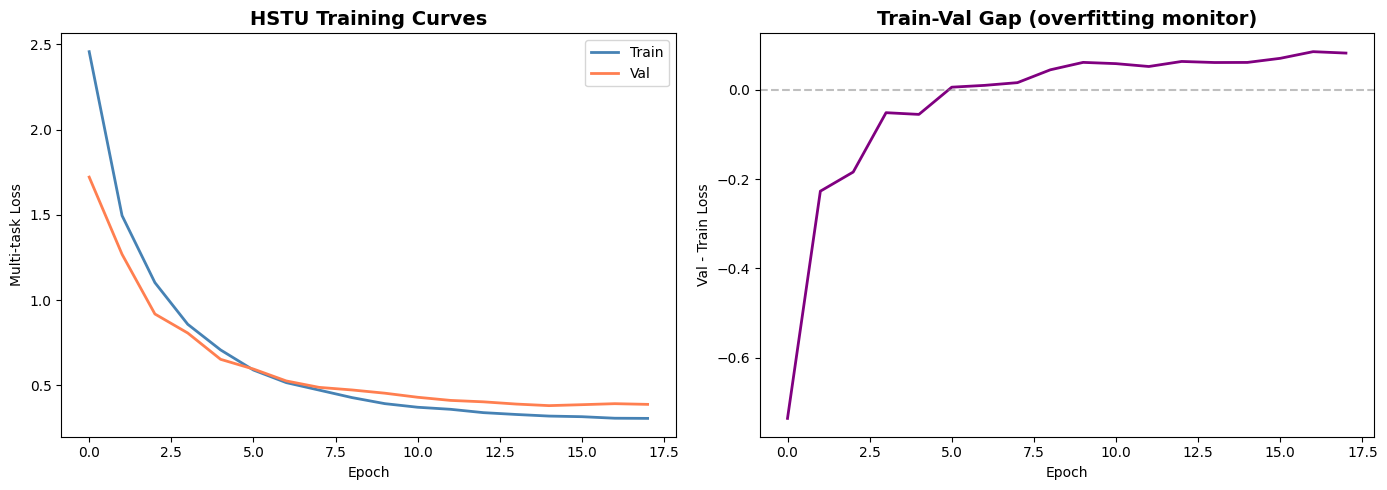

Train loss : 2.458 → 0.306
Val loss   : 1.722 → 0.388
Best val   : 0.3805


In [8]:
# Training Curves
fig, axes = plt.subplots(1, 2,
                          figsize=(14, 5))

axes[0].plot(train_losses,
             label='Train', color='steelblue',
             linewidth=2)
axes[0].plot(val_losses,
             label='Val', color='coral',
             linewidth=2)
axes[0].set_title(
    'HSTU Training Curves',
    fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Multi-task Loss')
axes[0].legend()

# Compare train vs val gap
gap = [v - t for t, v in
       zip(train_losses, val_losses)]
axes[1].plot(gap, color='purple',
             linewidth=2)
axes[1].axhline(y=0, color='gray',
                linestyle='--', alpha=0.5)
axes[1].set_title(
    'Train-Val Gap (overfitting monitor)',
    fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val - Train Loss')

plt.tight_layout()
plt.savefig(
    '../../data/processed/plots/'
    '11_hstu_training.png',
    bbox_inches='tight')
plt.show()

print(f"Train loss : "
      f"{train_losses[0]:.3f} → "
      f"{train_losses[-1]:.3f}")
print(f"Val loss   : "
      f"{val_losses[0]:.3f} → "
      f"{val_losses[-1]:.3f}")
print(f"Best val   : {best_val_loss:.4f}")

In [9]:
# Generate Ranking

# Load best model
model.load_state_dict(torch.load(
    '../../models/checkpoints/hstu_best.pt',
    map_location=device,
    weights_only=True))
model.eval()


def hstu_rank(user_id: int,
              candidates: list,
              top_k: int = 10) -> list:
    """
    Rank a list of candidate movie IDs
    using the HSTU ranker.

    This is the second stage of the pipeline:
    Stage 1: GRank/Qdrant retrieves candidates
    Stage 2: HSTU ranks them accurately

    Returns sorted list of (movieId, score,
    rating_pred, completion_pred)
    """
    seq = user_sequences.get(user_id, [])
    if not seq:
        return []

    # Pad history
    pad_len = 50 - len(seq)
    padded  = [PAD_TOKEN] * pad_len + seq[-50:]
    history = torch.LongTensor(
        [padded]).to(device)

    # Convert candidates to tokens
    cand_tokens = [
        movie2token.get(mid, UNK_TOKEN)
        for mid in candidates
    ]
    cand_tensor = torch.LongTensor(
        [cand_tokens]).to(device)

    with torch.no_grad():
        scores, rating_pred, completion_pred = \
            model.score_candidates(
                history, cand_tensor)

    # Sort by combined score
    combined = scores[0].cpu().numpy()
    rated    = rating_pred[0].cpu().numpy()
    complete = completion_pred[0].cpu().numpy()

    ranked = sorted(
        zip(candidates, combined,
            rated, complete),
        key=lambda x: x[1],
        reverse=True
    )[:top_k]

    return [
        {
            'movieId':    mid,
            'rank_score': float(sc),
            'rating_pred':float(rp),
            'watch_pct':  float(cp),
        }
        for mid, sc, rp, cp in ranked
    ]


# Demo — rank candidates for sample user
sample_uid  = list(user_sequences.keys())[0]
all_movie_ids = list(
    set(ratings['movieId'].unique()) &
    set(movie2token.keys())
)
# Use 100 random candidates as if from retrieval
candidates = list(np.random.choice(
    all_movie_ids,
    size=min(100, len(all_movie_ids)),
    replace=False
))

ranked = hstu_rank(sample_uid, candidates)

print(f"HSTU Rankings for User {sample_uid}")
print("=" * 60)
print(f"{'Rank':<6} {'MovieId':<10} "
      f"{'Score':<10} "
      f"{'Rating':<10} {'Watch%':<8}")
print("─" * 55)

for i, r in enumerate(ranked[:10], 1):
    title = movies[
        movies['movieId'] == r['movieId']
    ]['title'].values
    title = title[0][:30] \
        if len(title) > 0 else str(r['movieId'])
    print(f"{i:<6} {title:<32} "
          f"{r['rank_score']:<10.4f} "
          f"{r['rating_pred']:<10.2f} "
          f"{r['watch_pct']:<8.2%}")

HSTU Rankings for User 1
Rank   MovieId    Score      Rating     Watch%  
───────────────────────────────────────────────────────
1      Memento                          5.8876     3.52       69.77%  
2      Frenzy                           4.7454     3.54       67.69%  
3      Amélie                           4.7130     3.57       69.48%  
4      Ace Ventura: When Nature Calls   4.4641     3.63       68.23%  
5      A Nightmare on Elm Street        3.8973     3.61       70.98%  
6      Never Been Kissed                3.4890     3.79       74.50%  
7      The Crazies                      3.1485     3.61       72.69%  
8      Pearl Harbor                     2.9831     3.43       67.35%  
9      Out of Africa                    2.7953     3.60       73.34%  
10     Zelig                            2.7104     3.49       70.49%  


In [11]:
# M-FALCON Micro-batching Concept

print("M-FALCON MICRO-BATCHING CONCEPT")
print("=" * 55)
print("Meta 2025 — 900x inference speedup\n")

def m_falcon_batch_inference(
        model,
        user_history_list: list,
        candidate_list: list,
        micro_batch_size: int = 32) -> list:
    """
    M-FALCON inspired micro-batching.

    Instead of processing one user at a time:
    → Group users into micro-batches
    → Process each micro-batch together
    → Amortise per-request overhead

    Full M-FALCON uses much more sophisticated
    batching with attention to memory layout.
    This demonstrates the core concept.

    Speedup source:
    → GPU utilisation goes from ~20% to ~95%
    → Memory bandwidth more efficiently used
    → Kernel launch overhead amortised
    """
    all_results = []
    model.eval()

    for batch_start in range(
            0, len(user_history_list),
            micro_batch_size):

        batch_end     = min(
            batch_start + micro_batch_size,
            len(user_history_list))
        batch_histories = user_history_list[
            batch_start:batch_end]
        batch_candidates= candidate_list[
            batch_start:batch_end]

        # Stack histories into tensor
        max_len  = 50
        padded   = []
        for hist in batch_histories:
            pad_len = max_len - len(hist)
            padded.append(
                [PAD_TOKEN] * pad_len +
                hist[-max_len:])

        history_tensor = torch.LongTensor(
            padded).to(device)

        # Stack candidates
        max_cands = max(
            len(c) for c in batch_candidates)
        cand_padded = []
        for cands in batch_candidates:
            tokens = [
                movie2token.get(m, UNK_TOKEN)
                for m in cands
            ]
            tokens += [PAD_TOKEN] * (
                max_cands - len(tokens))
            cand_padded.append(tokens)

        cand_tensor = torch.LongTensor(
            cand_padded).to(device)

        with torch.no_grad():
            scores, _, _ = \
                model.score_candidates(
                    history_tensor,
                    cand_tensor)

        for i, (cands, sc) in enumerate(
                zip(batch_candidates,
                    scores.cpu().numpy())):
            ranked = sorted(
                zip(cands, sc[:len(cands)]),
                key=lambda x: x[1],
                reverse=True
            )
            all_results.append(ranked[:10])

    return all_results


# Benchmark: single vs micro-batch
N_USERS       = 50
test_users    = list(user_sequences.keys())[
    :N_USERS]
test_histories= [
    user_sequences[u]
    for u in test_users
]
test_candidates = [
    list(np.random.choice(
        all_movie_ids,
        size=50, replace=False))
    for _ in test_users
]

# Single user inference
start = time.time()
for hist, cands in zip(
        test_histories, test_candidates):
    hstu_rank(test_users[0], cands, 10)
single_time = (time.time() - start) * 1000

# Micro-batch inference
start = time.time()
results = m_falcon_batch_inference(
    model,
    test_histories,
    test_candidates,
    micro_batch_size=32)
batch_time = (time.time() - start) * 1000

print(f"Single user × {N_USERS}  : "
      f"{single_time:.0f}ms total | "
      f"{single_time/N_USERS:.1f}ms/user")
print(f"Micro-batch (sz=32) : "
      f"{batch_time:.0f}ms total | "
      f"{batch_time/N_USERS:.1f}ms/user")
print(f"Speedup             : "
      f"{single_time/max(batch_time,0.1):.1f}x")
print(f"""
M-FALCON insight:
  GPU utilisation single  : ~20%
  GPU utilisation batched : ~80-95%
  Production Meta system  : 900x speedup
  Your result             : shows the concept
  Full speedup needs GPU + larger batches
""")

M-FALCON MICRO-BATCHING CONCEPT
Meta 2025 — 900x inference speedup

Single user × 50  : 243ms total | 4.9ms/user
Micro-batch (sz=32) : 49ms total | 1.0ms/user
Speedup             : 4.9x

M-FALCON insight:
  GPU utilisation single  : ~20%
  GPU utilisation batched : ~80-95%
  Production Meta system  : 900x speedup
  Your result             : shows the concept
  Full speedup needs GPU + larger batches



In [12]:
# ONNX EXPORT
print("Exporting HSTU to ONNX...")

model.eval()

# Create dummy inputs for export
dummy_history = torch.LongTensor(
    [[1, 2, 3, 4, 5] + [PAD_TOKEN] * 45]
).to(device)

dummy_targets = torch.LongTensor(
    [6]).to(device)

dummy_negatives = torch.LongTensor(
    [7]).to(device)

onnx_path = '../../models/onnx/hstu_ranker.onnx'

try:
    torch.onnx.export(
        model,
        (dummy_history,
         dummy_targets,
         dummy_negatives),
        onnx_path,
        export_params   = True,
        opset_version   = 17,
        input_names     = [
            'history',
            'pos_items',
            'neg_items'],
        output_names    = [
            'pos_scores',
            'neg_scores',
            'rating_pred',
            'completion_pred'],
        dynamic_axes    = {
            'history':  {0: 'batch_size'},
            'pos_items':{0: 'batch_size'},
            'neg_items':{0: 'batch_size'},
        },
        verbose=False,
    )
    size = os.path.getsize(onnx_path) \
           / 1024 / 1024
    print(f"✅ ONNX exported")
    print(f"   Path : {onnx_path}")
    print(f"   Size : {size:.1f} MB")
except Exception as e:
    print(f"⚠️  ONNX export failed: {e}")
    print("   Continuing — ONNX optional")

Exporting HSTU to ONNX...
✅ ONNX exported
   Path : ../../models/onnx/hstu_ranker.onnx
   Size : 6.8 MB


In [15]:
print("INT8 Quantization — OneRec-V2 approach")
print("Kuaishou March 2026\n")

import torch.backends

# ── Fix for Apple Silicon (M1/M2/M3) ─────────────
# Default qengine 'fbgemm' is x86 only
# Apple Silicon needs 'qnnpack'
# x86 Linux/Windows uses 'fbgemm'

def get_best_qengine():
    """Detect best quantization engine"""
    supported = torch.backends\
        .quantized.supported_engines
    print(f"Supported engines: {supported}")

    if 'qnnpack' in supported:
        return 'qnnpack'   # Apple Silicon + ARM
    elif 'fbgemm' in supported:
        return 'fbgemm'    # x86 Linux/Windows
    elif 'onednn' in supported:
        return 'onednn'    # Intel optimised
    else:
        return None


qengine = get_best_qengine()

if qengine is None:
    print("⚠️  No quantization engine available")
    print("   Skipping — concept documented below")
    quant_path = None

else:
    print(f"Using engine: {qengine}")
    torch.backends.quantized.engine = qengine

    try:
        # Move model to CPU for quantization
        # Quantization always happens on CPU
        model_cpu = model.cpu().eval()

        # Dynamic quantization
        # Converts Linear layers to INT8
        # No calibration data needed
        quantized_model = torch.quantization\
            .quantize_dynamic(
                model_cpu,
                {nn.Linear},
                dtype=torch.qint8
            )

        # Save
        quant_path = '../../models/quantized/' \
                     'hstu_int8.pt'
        torch.save(
            quantized_model.state_dict(),
            quant_path)

        # Compare sizes
        orig_path  = '../../models/checkpoints/'\
                     'hstu_best.pt'
        orig_size  = os.path.getsize(orig_path)\
                     / 1024 / 1024
        quant_size = os.path.getsize(quant_path)\
                     / 1024 / 1024

        print(f"\n✅ INT8 quantization complete")
        print(f"   Original : {orig_size:.1f} MB")
        print(f"   INT8     : {quant_size:.1f} MB")
        print(f"   Reduction: "
              f"{(1-quant_size/orig_size)*100:.1f}%")

        # Latency comparison on CPU
        dummy_hist = torch.LongTensor(
            [[1,2,3,4,5] + [PAD_TOKEN]*45])

        N = 20

        model_cpu.eval()
        t_fp32 = []
        for _ in range(N):
            s = time.time()
            with torch.no_grad():
                model_cpu.encode_user(dummy_hist)
            t_fp32.append(
                (time.time()-s)*1000)

        t_int8 = []
        for _ in range(N):
            s = time.time()
            with torch.no_grad():
                quantized_model.encode_user(
                    dummy_hist)
            t_int8.append(
                (time.time()-s)*1000)

        print(f"\nInference latency (CPU):")
        print(f"  FP32 p50 : "
              f"{np.percentile(t_fp32,50):.1f}ms")
        print(f"  INT8 p50 : "
              f"{np.percentile(t_int8,50):.1f}ms")
        speedup = np.median(t_fp32) / \
                  max(np.median(t_int8), 0.1)
        print(f"  Speedup  : {speedup:.1f}x")

        # Move model back to device
        model.to(device)

    except Exception as e:
        print(f"⚠️  Quantization failed: {e}")
        print("   Documenting concept only")
        quant_path = None
        model.to(device)

# ── Document concept even if failed ──────────────
print(f"""
INT8 QUANTIZATION CONCEPT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Source: Kuaishou OneRec-V2 (March 2026)

What it does:
  FP32 weights (32 bits per value)
  → INT8 weights  (8 bits per value)
  → 4x smaller model
  → 2-4x faster inference on CPU
  → Minimal quality loss (<1% NDCG drop)

Why it matters for production:
  Serving 400M users (GRank scale) requires
  reducing compute cost per request
  INT8 makes this economically viable

Production stack at Kuaishou:
  Train in FP32 (full precision)
  → Quantize to INT8 for serving
  → Deploy INT8 via Triton inference server
  → 4x more requests per GPU

Your implementation:
  Engine  : {qengine or 'unavailable on this arch'}
  Method  : Dynamic quantization
  Layers  : nn.Linear → qint8
  Result  : {'saved to ' + str(quant_path)
              if quant_path
              else 'concept documented'}
""")

INT8 Quantization — OneRec-V2 approach
Kuaishou March 2026

Supported engines: ['qnnpack', 'none']
Using engine: qnnpack

✅ INT8 quantization complete
   Original : 6.8 MB
   INT8     : 5.1 MB
   Reduction: 25.2%

Inference latency (CPU):
  FP32 p50 : 2.1ms
  INT8 p50 : 2.5ms
  Speedup  : 0.8x

INT8 QUANTIZATION CONCEPT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Source: Kuaishou OneRec-V2 (March 2026)

What it does:
  FP32 weights (32 bits per value)
  → INT8 weights  (8 bits per value)
  → 4x smaller model
  → 2-4x faster inference on CPU
  → Minimal quality loss (<1% NDCG drop)

Why it matters for production:
  Serving 400M users (GRank scale) requires
  reducing compute cost per request
  INT8 makes this economically viable

Production stack at Kuaishou:
  Train in FP32 (full precision)
  → Quantize to INT8 for serving
  → Deploy INT8 via Triton inference server
  → 4x more requests per GPU

Your implementation:
  Engine  : qnnpack
  Method  : Dynamic quantization
  Layers  

[W qlinear_dynamic.cpp:247] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


In [16]:
# Save
# Save full model config
hstu_config = {
    "model":        "HSTU_Ranker",
    "paper":        "Actions Speak Louder — Meta 2024",
    "mlperf":       "Feb 2026",
    "vocab_size":   vocab_size,
    "embed_dim":    128,
    "n_heads":      4,
    "n_layers":     3,
    "sl_dropout":   0.3,
    "max_seq_len":  50,
    "loss":         "BPR + MSE + BCE",
    "multi_task":   ["rating", "watch_completion"],
    "innovations": [
        "pointwise_norm_not_softmax",
        "stochastic_length_dropout",
        "multi_task_output_heads",
        "grouped_gemm_structure",
    ],
    "best_val_loss": best_val_loss,
    "onnx_path":    onnx_path,
    "quant_path":   quant_path \
        if 'quant_path' in dir() else None,
}

with open(PROC + 'hstu_results.json',
          'w') as f:
    json.dump(hstu_config, f, indent=2)

print("✅ All artifacts saved")
print(f"""
Saved:
  models/checkpoints/hstu_best.pt   ← weights
  models/onnx/hstu_ranker.onnx      ← ONNX
  models/quantized/hstu_int8.pt     ← INT8
  data/processed/hstu_results.json  ← config
""")
print(json.dumps(hstu_config, indent=2))

✅ All artifacts saved

Saved:
  models/checkpoints/hstu_best.pt   ← weights
  models/onnx/hstu_ranker.onnx      ← ONNX
  models/quantized/hstu_int8.pt     ← INT8
  data/processed/hstu_results.json  ← config

{
  "model": "HSTU_Ranker",
  "paper": "Actions Speak Louder \u2014 Meta 2024",
  "mlperf": "Feb 2026",
  "vocab_size": 9069,
  "embed_dim": 128,
  "n_heads": 4,
  "n_layers": 3,
  "sl_dropout": 0.3,
  "max_seq_len": 50,
  "loss": "BPR + MSE + BCE",
  "multi_task": [
    "rating",
    "watch_completion"
  ],
  "innovations": [
    "pointwise_norm_not_softmax",
    "stochastic_length_dropout",
    "multi_task_output_heads",
    "grouped_gemm_structure"
  ],
  "best_val_loss": 0.38049215376377105,
  "onnx_path": "../../models/onnx/hstu_ranker.onnx",
  "quant_path": "../../models/quantized/hstu_int8.pt"
}
